# Customer Churn Analysis

## Objective

The objective of this project is to analyze customer churn using the IBM Telco Customer Churn dataset.

The project involves:

- Data Cleaning using Python
- Exploratory Data Analysis
- Data Visualization
- SQL Business Analysis
- Interactive Power BI Dashboard
- Customer Churn Prediction (Machine Learning)

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)


> The dataset contains **7,043 customer records** and **21 columns**.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


>### Key Understanding
Most columns are of **object** type, while `SeniorCitizen` is an integer and `MonthlyCharges` is a float.  

The `TotalCharges` column is stored as an **object** instead of a numeric type and requires conversion before analysis.

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['TotalCharges'].head()

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: object

In [8]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = df['TotalCharges'].astype(float)
df['TotalCharges'].dtype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


>The **TotalCharges** column was converted from **object** to **float** to enable numerical analysis and visualization.

>Replaced blank values with NaN and handled missing records.

In [9]:
df.shape

(7043, 21)

In [10]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [12]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Data Cleaning Summary

- Converted the `TotalCharges` column from **object** to **float** for numerical analysis.
- Blank values in the `TotalCharges` column were replaced with **NaN**.
- Missing values in `TotalCharges` were imputed using the **median**.  
- Verified that the dataset contains **no duplicate records**.
- Confirmed that the dataset has **no remaining missing values** after preprocessing.
- The cleaned dataset is now ready for Exploratory Data Analysis (EDA).

------------------------------------------------------------------------------------------------------------------------

------------------------------------------------------------------------------------------------------------------------

# EDA


1. overall churn rate - 

In [13]:
# Count customers who churned and who stayed
df['Churn'].value_counts()


Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [14]:
# Calculate the percentage of customers in each churn category
# normalize=True divides each count by the total number of customers
df['Churn'].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

Example( normalize=True ) - for NO(stayed) 5174 / 7043 and for yes(churned) 1869/7043
if normalize= False we will get counts not %

value_counts() sorts categories by their frequency in descending order. Since more customers did not churn (No) 
than churned (Yes), 
No appears first in the output.

### # Insight

Out of 7,043 customers, 1,869 customers churned while 5,174 customers stayed.  
The overall churn rate is approximately **26.54%**, meaning around **1 in every 4 customers** left the company.  
This indicates a noticeable retention issue and shows the importance of identifying high-risk customer segments.

------------------------------------------------------------------------------------------------------------------

2. Churn by gender -


In [15]:
pd.crosstab(df['gender'], df['Churn'])
pd.crosstab(df['gender'],df['Churn'],normalize='index')*100

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


### Insight

Male and female customers have almost the same churn rate, around 26%.  
This shows that gender does not make much difference in customer churn.

----------------------------------------------------------------------------------------------------------------------


3. Churn By Contract Type -

In [16]:
pd.crosstab(df['Contract'], df['Churn'])
pd.crosstab(df['Contract'], df['Churn'],normalize='index')*100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


### Insight

Month-to-month customers have the highest churn rate.  
Customers with one-year and two-year contracts have lower churn rates.  
This shows that churn decreases as contract duration increases.

---------------------------------------------------------------------------------------------------------------------

4. Churn by Payment Method -


In [17]:
pd.crosstab(df['PaymentMethod'], df['Churn'])
pd.crosstab(df['PaymentMethod'], df['Churn'],normalize='index')*100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


### Insight

Electronic Check users have the highest churn rate, around 45%.  
Customers using other payment methods have comparatively lower churn rates.

----------------------------------------------------------


5. Churn by Internet service type -

In [18]:
pd.crosstab(df['InternetService'], df['Churn'])
pd.crosstab(df['InternetService'],df['Churn'], normalize='index') * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


### Insight

Fiber Optic customers have the highest churn rate.  
DSL customers and customers without internet service have lower churn rates.

----------------------------------------------------------

6. Average Monthly Charges

In [19]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

### Insight

Customers who churned have higher average monthly charges than customers who stayed.  
This suggests that customers paying higher monthly fees are more likely to leave the company.

------------------------------------------------------------------

7. Average Total Charges

In [20]:
df.groupby('Churn')['TotalCharges'].mean()

Churn
No     2552.882494
Yes    1531.796094
Name: TotalCharges, dtype: float64

### Insight

Customers who stayed have higher average total charges than customers who churned.  
This indicates that long-term customers contribute more revenue, while customers who leave have lower total charges because they have spent less time with the company.

------------------------------------------------------------------

8. Average Tenure

In [21]:
df.groupby('Churn')['tenure'].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

### Insight

Customers who stayed with the company have an average tenure of about 38 months.  
Customers who churned have an average tenure of about 18 months.  
This shows that customers with lower tenure are more likely to leave the company.

------------------------------------------------------------------

9. Churn by senior citizen

In [22]:
pd.crosstab(df['SeniorCitizen'], df['Churn'],normalize='index') * 100

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


### Insight

Senior citizens have a higher churn rate of around 42%, while non-senior customers have a churn rate of around 24%.  
This shows that senior citizens are more likely to leave the company than non-senior customers.

In [23]:
df.to_csv('customer_churned_cleaned.csv',index=False)

------------------------------------------------------------------

# EDA Visualization 

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

1. Overall Churn Distribution

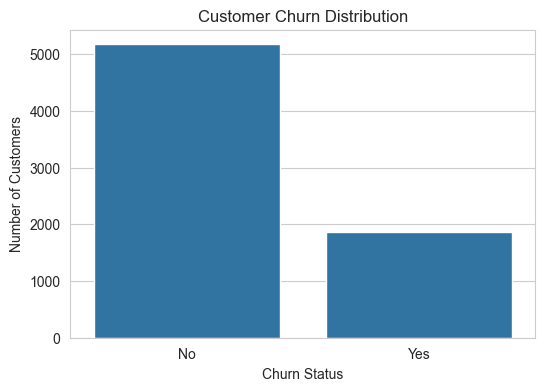

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')

plt.show()

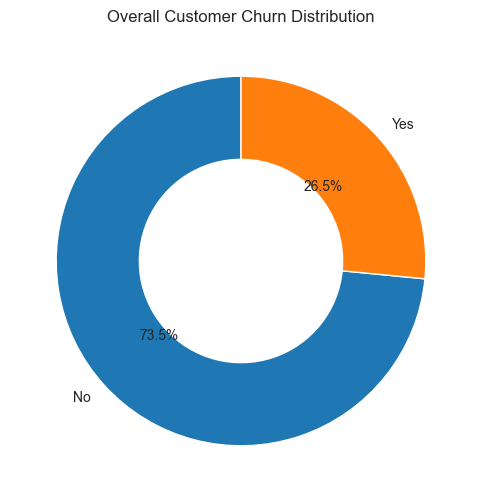

In [27]:
# Overall Customer Churn Distribution - Donut Chart

churn_counts = df['Churn'].value_counts()
plt.figure(figsize=(6, 6))

plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.45, 'edgecolor': 'white'}
)

plt.title('Overall Customer Churn Distribution')
plt.show()

### Insight:
Most customers stayed with the company, but around 26.5% customers churned. This shows that customer churn is a significant issue for the company.

------------------------------------------------------------------

2. Churn Rate by Contract Type

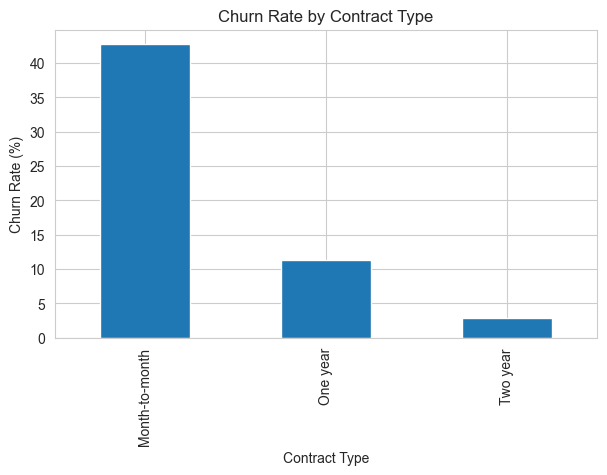

In [28]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index') * 100

contract_churn['Yes'].plot(kind='bar', figsize=(7,4))

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.show()

### Insight:
Month-to-month customers have the highest churn rate, while two-year contract customers have the lowest churn rate. Longer contracts are associated with lower customer churn.

------------------------------------------------------------------

3. Churn rate by Payment Method

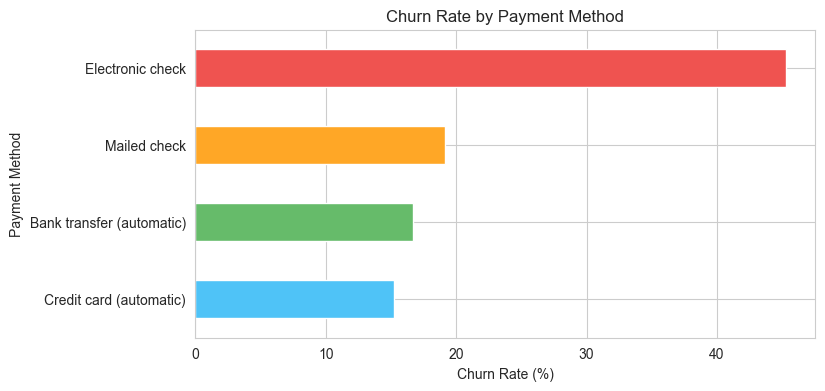

In [31]:
payment_churn = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index') * 100

payment_churn['Yes'].sort_values().plot(
    kind='barh',
    figsize=(8,4),
    color=['#4FC3F7', '#66BB6A', '#FFA726', '#EF5350', '#AB47BC']
)

plt.title('Churn Rate by Payment Method')
plt.xlabel('Churn Rate (%)')
plt.ylabel('Payment Method')

plt.show()

### Insight:
Electronic check users have the highest churn rate. Customers using automatic payment methods have lower churn rates.

------------------------------------------------------------------

4. Churn rate by internet service


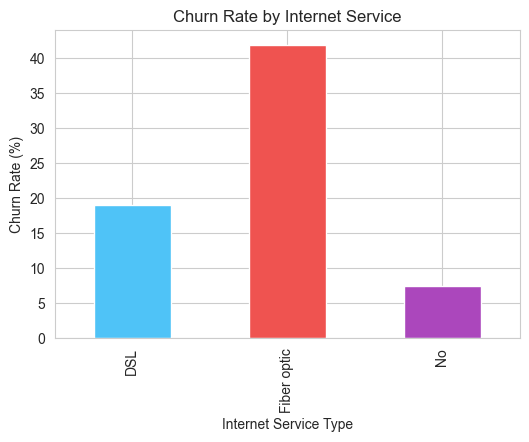

In [39]:
internet_churn = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index') * 100

internet_churn['Yes'].plot(kind='bar', figsize=(6,4),
        color=['#4FC3F7', '#EF5350', '#AB47BC'])

plt.title('Churn Rate by Internet Service')
plt.xlabel('Internet Service Type')
plt.ylabel('Churn Rate (%)')

plt.show()

### Insight:
Fiber optic customers have the highest churn rate, while customers without internet service have the lowest churn rate.

------------------------------------------------------------------

5. Monthly Charges vs Churn

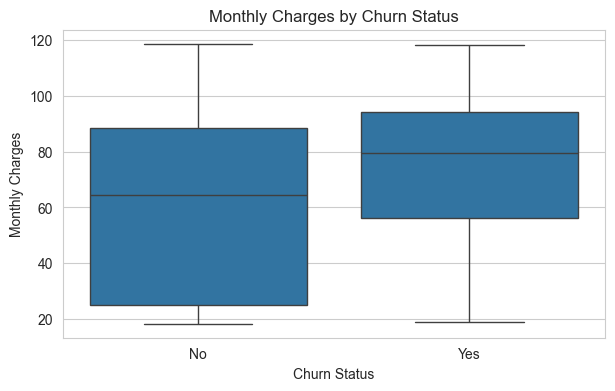

In [61]:
plt.figure(figsize=(7,4))

sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges'
)

plt.title('Monthly Charges by Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Monthly Charges')

plt.show()

### Insight:
Customers who churned generally have higher monthly charges than customers who stayed. Higher monthly fees may be linked with customer churn.

------------------------------------------------------------------

6. Tenure vs Churn

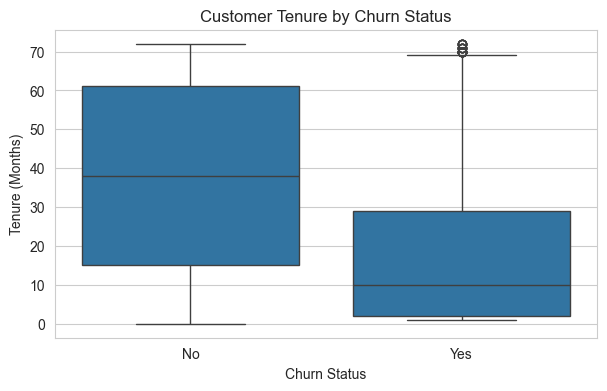

In [63]:
plt.figure(figsize=(7,4))

sns.boxplot(
    data=df,
    x='Churn',
    y='tenure'
)

plt.title('Customer Tenure by Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Tenure (Months)')

plt.show()

### Insight:
Customers who churned have lower average tenure than customers who stayed. Newer customers are more likely to leave the company.

------------------------------------------------------------------

7. Correlation Heatmap

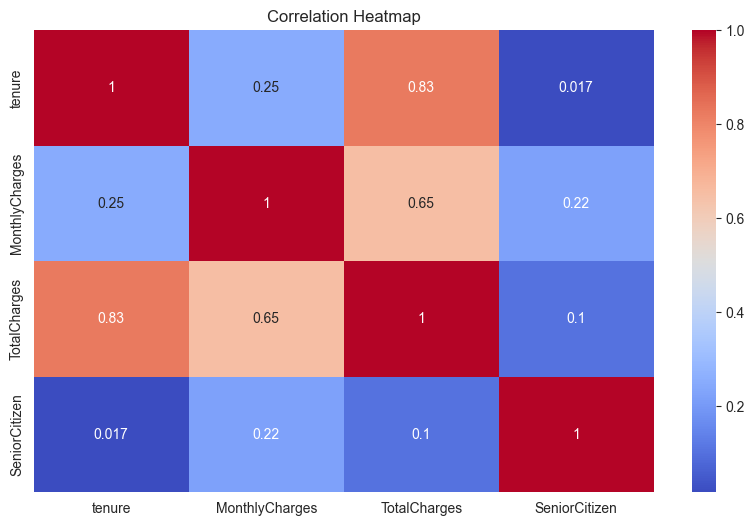

In [38]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['tenure','MonthlyCharges',
    'TotalCharges','SeniorCitizen']].corr(), 
    annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Insights :

- **TotalCharges & tenure (0.83)** — Strong positive correlation. 
  Customers who stay longer naturally accumulate higher total charges.

- **MonthlyCharges & TotalCharges (0.65)** — Moderate correlation. 
  Higher monthly plans contribute to higher total spend.

- **MonthlyCharges & tenure (0.25)** — Weak correlation. 
  Long-term customers don't necessarily pay higher monthly rates.

- **SeniorCitizen shows very weak correlation with all variables** — 
  Senior status alone doesn't strongly predict charges or tenure.

- **Key takeaway:** Tenure is the strongest indicator of total revenue 
  contribution. Retaining customers longer = significantly more revenue.

---

---